#### HW1 pt.1: 6 coding tasks

* For each task you can get either max or 0 points.

* If you use any sources to solve the HW, you must cite them.

* No plagiarism accepted, cheating will be penalised

* You must be able to explain your solution during the oral exam session

* LLMs are allowed, but again, you must be able to explain your solution

In [1]:
# download data
!mkdir data
!wget -O./data/Acetone.xyz https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/hw1/Acetone.xyz
!wget -O./data/VOPO4_new.cif https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/hw1/VOPO4_new.cif
!wget -O./data/diffusivity.csv https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/hw1/diffusivity.csv


mkdir: data: File exists
--2026-10-07 22:36:29--  https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/hw1/Acetone.xyz
Распознаётся raw.githubusercontent.com (raw.githubusercontent.com)… 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Подключение к raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 413 [text/plain]
Сохранение в: «./data/Acetone.xyz»

./data/Acetone.xyz  100%[===================>]     413  --.-KB/s    за 0s      

2026-10-07 22:36:31 (32,8 MB/s) - «./data/Acetone.xyz» сохранён [413/413]

--2026-10-07 22:36:31--  https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/hw1/VOPO4_new.cif
Распознаётся raw.githubusercontent.com (raw.githubusercontent.com)… 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Подключение к raw.githubusercontent.com (raw.githubusercontent.com)|185.199.11

In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Task 1. Favorite sorting algo (5 points)
Write a function that takes an 1xN array of numbers and return its sorted version. Use of built-in sort function is prohibited. Compare correctness and the speed of your solution with the numpy's sort() method.

Note: Use loop, if/else


In [3]:
def my_sorting_function(arr):

    """
    This function sort given array in ascending order

    Parameters
    ----------

    array: array of numbers, e.g. [1.3, 5.2, 3.5, -7.1, 7]

    Returns
    ----------
    sorted in ascending order array
    """

    n = len(arr)

    # Note: change arr in place, i.e. using slicing/indexing

    if len(arr) <= 1:
            return arr

    mid = len(arr) // 2
    left = my_sorting_function(arr[:mid])
    right = my_sorting_function(arr[mid:])

    i = j = k = 0
    merged = []

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])

    return merged


# create array
arr = np.arange(500)

# randomly shuffle array
np.random.shuffle(arr)

# sort the array using your function

sorted_array = my_sorting_function(arr.copy())

 # distance between sorted arrays should be zero. If no error raised you passed this task
assert abs(sorted_array - np.sort(arr)).sum() == 0


In [4]:
# compare the speed of your solution with np.sort

In [5]:
from time import time
arr = np.arange(500)

# randomly shuffle array
np.random.shuffle(arr)

start = time()
sorted_array = my_sorting_function(arr.copy())
print(time() - start)

0.0006868839263916016


In [6]:
from time import time
arr = np.arange(500)

# randomly shuffle array
np.random.shuffle(arr)

start = time()
sorted_array = np.sort(arr)
print(time() - start)

0.0004169940948486328


#### Task 2. Nearest neighbor (5 points)
A set of points is given in 3D cartesian space. Write a function that finds the nearest neighbour of the first point and returns its index and the distance between the neighbour and the point. Compare your result with the KDtree approach.

Tip: Use np.linalg.norm to calculate the distance between two (or more) points.

In [7]:
def nn(points):

    """
    Given a list of points, this function finds the nearest neighbour of the first point.

    Parameters
    ----------

    points: array of cartesian coordinates of shape Nx3

    Returns
    ----------
    index of the nearest neighbor to the first point and distance between them
    """

    p0 = points[0]
    p_rest = points[1:]
    distance, nn_id  = None, None
    distance = np.sqrt(np.sum((p_rest - p0) ** 2, axis=1))
    nn_id = np.argmin(distance)
    distance_v = np.min(distance)
    return distance_v, nn_id


x, y, z = np.random.normal(size = 100, scale = 100), np.random.normal(size = 100, scale = 100), np.random.normal(size = 100, scale = 100)
points = np.vstack([x, y, z]).T


# cKDtree solution
from scipy.spatial import cKDTree
tree = cKDTree(points[1:])
d1, nn_id1 = tree.query(points[0])

# your solution
d2, nn_id2 = nn(points)

assert abs(d1 - d2) < 1e-10 # compare your solution with scipy
assert nn_id1 == nn_id2

In [8]:
nn(points)

(47.84512852783544, 53)

#### Task 3. Nearest neighbor in periodic lattice (5 points)
Given a set of points in 2D subject to periodic boundary conditions (pbc). The periodic box is square. The period is 1.0.

Write a function that finds the nearest neighbour of the first point and returns its index and the distance between the neighbour and the point, taking into account the pbc. Compare your result with the KDtree approach.

Note: You need to calculate the distance between the first point and each point inside the periodic box and its replicas translated by translation vectors.

In [9]:
translations = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0], [-1.0, 0.0], [0.0, -1.0], [-1.0, 1.0], [1.0, -1.0],[-1.0, -1.0], [1.0, 1.0]])


def periodic_nn(points, translations):
    p0 = points[0]
    p_rest = points[1:]
    replicas = p_rest[:, None, :] + translations[None, :, :]
    diffs = replicas - p0
    sq_dists = np.sum(diffs ** 2, axis=2)
    min_sq_per_point = np.min(sq_dists, axis=1)
    nn_id = np.argmin(min_sq_per_point)
    best_sq = min_sq_per_point[nn_id]

    nn_translation = translations[np.argmin(sq_dists[nn_id])]

    distance = np.sqrt(best_sq)

    return distance, nn_id, nn_translation

x, y = np.random.uniform(low=0.0, high=1.0, size=(50,)), np.random.uniform(low=0.0, high=1.0, size=(50,))
points = np.vstack([x, y]).T


# cKDtree solution
from scipy.spatial import cKDTree
tree = cKDTree(points[1:], boxsize = [1.0, 1.0])
d1, nn_id1 = tree.query(points[0])

#your solution
d2, nn_id2, nn_translation = periodic_nn(points, translations)

assert abs(d1 - d2) < 1e-10 # compare your solution with scipy
assert nn_id1 == nn_id2



In [10]:
periodic_nn(points, translations)

(0.10862944863686234, 17, array([0., 0.]))

##### Task 4. Surface slicing (5 points).
Given a surface zz(x, y).
- Plot the surface # (2 points)

- Plot its slice at the x = 0. Find the global minimum value of the line obtained after slicing zz(x, y) at the x = 0 # (2 points)
- Plot the coutourplot for the slice at the zz = 11.2 and 11.0 (1 point)

Global minimum at x=0: z = 10.000000 at y = 0.000000


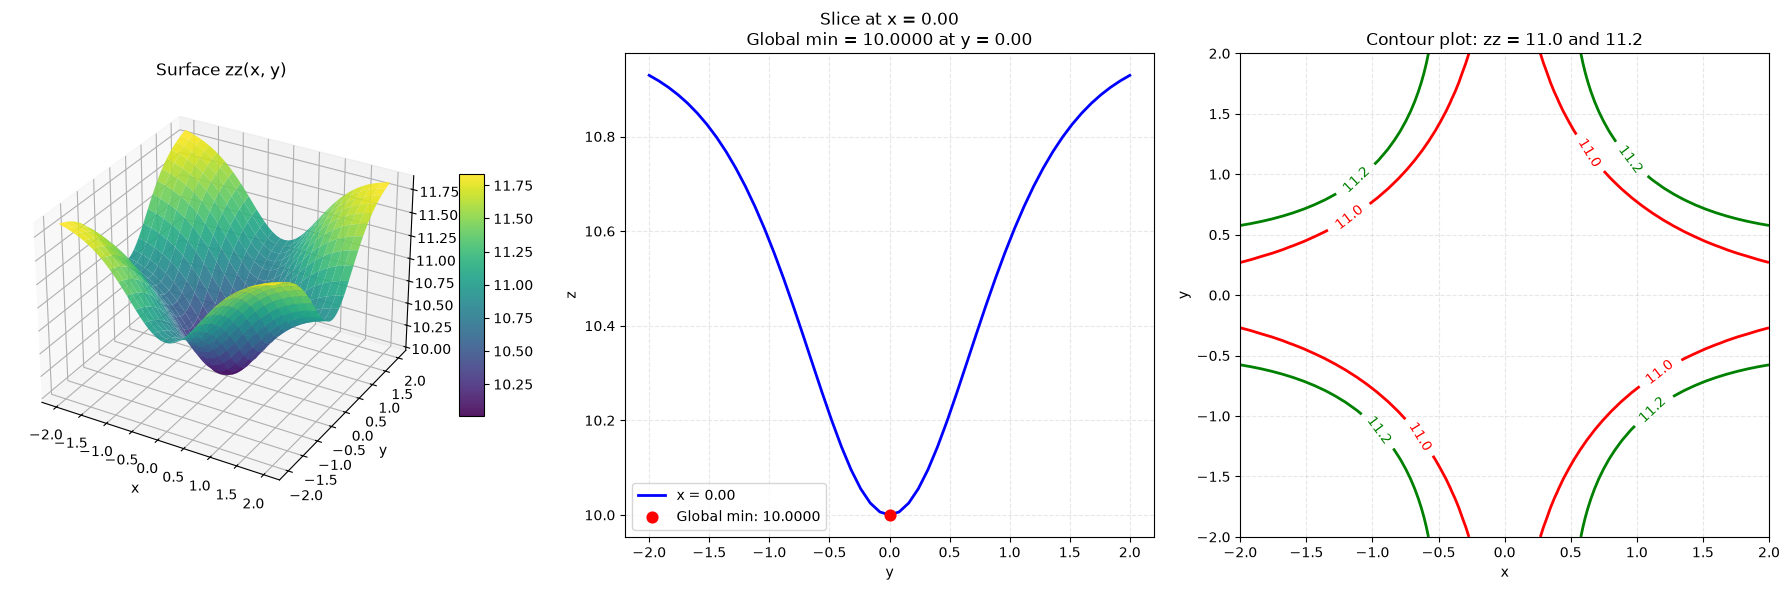

In [11]:
from matplotlib import cm

N = 51
x, y = np.linspace(-2, 2, N), np.linspace(-2, 2, N)
xx, yy = np.meshgrid(x,y)

# define surface
zz = 10 + np.tanh(xx)**2 + (np.tanh(yy))**2


### your code here
fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(xx, yy, zz, cmap='viridis', alpha=0.9, edgecolor='none')
ax1.set_title('Surface zz(x, y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)


idx_x0 = np.argmin(np.abs(x - 0))
x0_val = x[idx_x0]

slice_y = y
slice_z = zz[idx_x0, :]


min_val = np.min(slice_z)
min_y_idx = np.argmin(slice_z)
min_y = slice_y[min_y_idx]

ax2 = fig.add_subplot(132)
ax2.plot(slice_y, slice_z, label=f'x = {x0_val:.2f}', color='blue', linewidth=2)
ax2.scatter([min_y], [min_val], color='red', s=60, zorder=3, label=f'Global min: {min_val:.4f}')
ax2.set_title(f'Slice at x = {x0_val:.2f}\nGlobal min = {min_val:.4f} at y = {min_y:.2f}')
ax2.set_xlabel('y')
ax2.set_ylabel('z')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.3)

print(f"Global minimum at x=0: z = {min_val:.6f} at y = {min_y:.6f}")

ax3 = fig.add_subplot(133)
contour_levels = [11.0, 11.2]
cont = ax3.contour(xx, yy, zz, levels=contour_levels, colors=['red', 'green'], linewidths=2)
ax3.clabel(cont, inline=True, fontsize=10, fmt='%.1f')
ax3.set_title('Contour plot: zz = 11.0 and 11.2')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



In [12]:
# plot the contour plot for the slice at the zz = 11.2 and 11.0 (1 point)
# plot slice at the x = 0. Find the global minimum value of the line obtained after slicing zz(x, y) at the x = 0 # (2 points)

#### Task 5. Linear regression (5 points)

Note: https://en.wikipedia.org/wiki/Linear_regression


Given a dataframe (data/diffusivity.csv) with columns "temperature" and "diffusivity".

- Plot 1/temperature vs. log10(diffusivity).

- Perfrom a linear regression analysis (1/temperature vs. log10(diffusivity)).

- Plot the fit line at the same figure. Predict the diffusivity at 300 K.

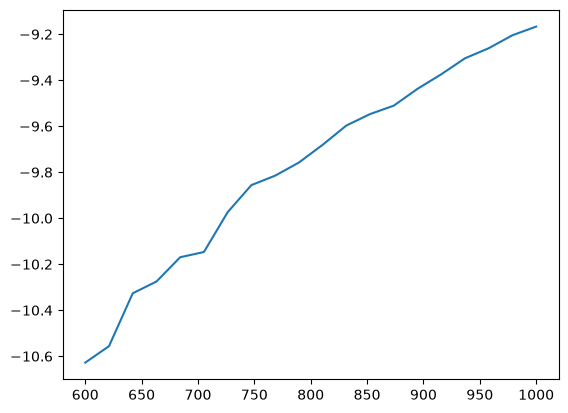

In [13]:
from scipy.stats import linregress
import pandas as pd


D = None # D(T = 300 K)

### your code here ###

df = pd.read_csv('data/diffusivity.csv')
plt.plot(df['temperature'], np.log10(df['diffusivity']))

Predicted diffusivity at T = 300.0 K: 5.251408e-15


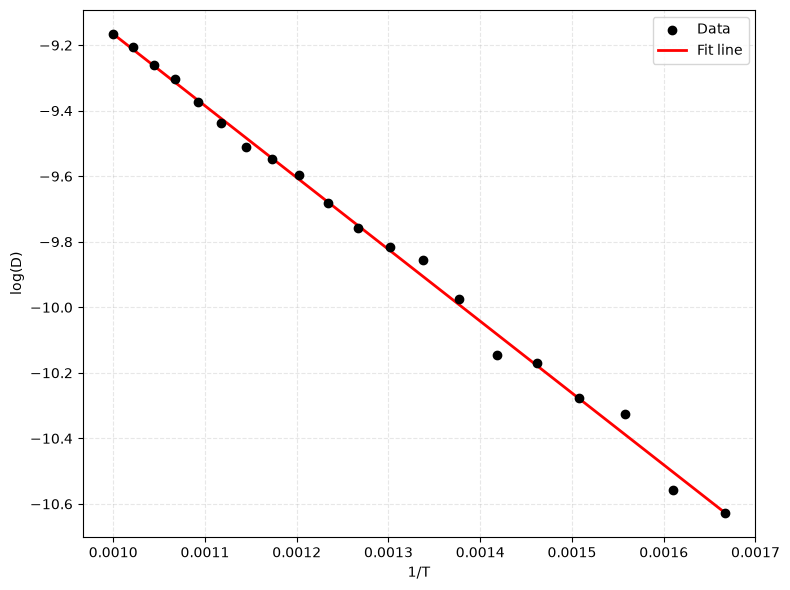

In [14]:

T = df['temperature'].values
D = df['diffusivity'].values

x = 1.0 / T
y = np.log10(D)

slope, intercept, r_value, p_value, std_err = linregress(x, y)


T_pred = 300.0
x_pred = 1.0 / T_pred
y_pred = slope * x_pred + intercept
D_pred = 10 ** y_pred

D = D_pred

print(f"Predicted diffusivity at T = {T_pred} K: {D:.6e}")

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='black', label='Data', zorder=3)


x_line = np.linspace(min(x), max(x), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', linewidth=2, label='Fit line')

plt.xlabel('1/T')
plt.ylabel('log(D)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


#### Task 6: Adjacency matrix (5 points)
Given an .xyz file for acetone molecule

- read the structure using ASE
- plot (or print out) the connectivity matrix (the adjacency matrix) for this molecule.

- use natural cutoffs for extracting nearest neighbors (ase.neighborlist.natural_cutoffs)



In [15]:
!pip install ase


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [16]:

from ase.io import read
from ase.neighborlist import natural_cutoffs, NeighborList
import numpy as np

file = 'data/Acetone.xyz'


atoms = read(file)

cutoffs = natural_cutoffs(atoms)

nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
nl.update(atoms)

n_atoms = len(atoms)
adj_matrix = np.zeros((n_atoms, n_atoms), dtype=int)

for i in range(n_atoms):
    indices, offsets = nl.get_neighbors(i)
    adj_matrix[i, indices] = 1



print(adj_matrix)

[[0 1 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 1 1]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]]


#### HW1 pt.2: Vanadium phosphates

- (5 points) Download the crystal structures of vanadium phosphates deposited at The Materials project database using its API
- (5 points) Decorate crystal structures with oxidation states using pymatgen's BVAnalyzer. Discard structures for which BVAnalyzer does not work.

- (10 points) Obtain a pandas dataframe with the following columns: ['min_VO_bond_length', 'vanadium_oxidation_state', 'effective_coordination_number'] for the downloaded compounds

- (5 points) Plot the distribution of the minimum V-O distances for each oxidation state of V. Compare your results with the literature.
    - https://link.springer.com/article/10.1134/S1063774509020059

    - https://journals.iucr.org/m/issues/2020/04/00/lt5028/

- (5 points) Plot the distribution of effective coordination number of V for each oxidation state

- (10 points) What is the correlation between the min V-O bond length and oxidation state of V? Perform linear regression analysis. Report parameters of the fitted line.

- (5 points) Your Super Duper AI Crystal Structure Generator has generated a new VOPO4 polymorph (data/VOPO4_new.cif). Is this structure feasible? Answer in the light of the data you have obtained.


In [17]:
!pip install pymatgen mp_api


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [18]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymatgen.core import Structure
from pymatgen.analysis.local_env import VoronoiNN
from mp_api.client import MPRester
from pymatgen.analysis.bond_valence import BVAnalyzer

/Users/ayagolubkova/rl/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.6.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(
/Users/ayagolubkova/rl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("API_KEY")



In [20]:
# Download structures

# https://api.materialsproject.org/docs#/Summary/search_summary__get

with MPRester(api_key) as mpr:
    docs = mpr.materials.summary.search(
        chemsys="V-P-O",
        fields=["material_id", "formula_pretty", "structure"],
    )

print(f"Downloaded {len(docs)} V-P-O structures")

Retrieving SummaryDoc documents: 100%|██████████| 107/107 [00:00<00:00, 923437.30it/s]

Downloaded 107 V-P-O structures


In [21]:
# Decorate structures with oxidation states
def get_oxi_state_decorated_structure(st):

    """
    This function decorates a pymatgen's Structure
    with oxidation states

    Params
    ------
    st: pymatgen's Structure

    Returns
    -------
    st_decorated: decorated Structure
    """

    analyzer = BVAnalyzer()
    return analyzer.get_oxi_state_decorated_structure(st)


structures = []
for doc in docs:
    try:
        structures.append(get_oxi_state_decorated_structure(doc.structure))
    except Exception:
        # BVAnalyzer cannot assign a unique, charge-balanced set of valences
        pass

print(f"Kept {len(structures)} structures; discarded {len(docs) - len(structures)}")

spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.


Kept 89 structures; discarded 18


In [22]:
def _effective_coordination_number(face_areas):
    """
    This function calculated effective coordination number

    Params
    ------
    face_areas: numpy array
        face areas of the Voronoi polyhedron

    Returns

    effective coordination number
    defined as the square of the sum of the face areas divided by the sum of the squares of the face areas

    """

    face_areas = np.asarray(face_areas, dtype=float)
    return (np.sum(face_areas) ** 2) / np.sum(face_areas ** 2)


# Calculate CN and bond distances
data = {
            'min_VO_bond_length': [],
            'mean_VO_bond_length': [],
            'vanadium_oxidation_state': [],
            'coordination_number': [],
            'effective_coordination_number': [],
        }


def get_features(poly_data):


    """
    This function calculates geomtrical features
    associated with the VOreonoi polyhedron

    Params
    ------
    poly_data: dictionary
        The data is derrived using Voronoi partitioning as implemented
        in pymatgen's VoronoiNN.get_voronoi_polyhedra method


    Returns
    -------
    minimum V-O distance, mean V-O distance, coordination number, effective coordination_number
    """

    distances = []
    face_areas = []
    for site_id in poly_data.keys():
        neighbor = poly_data[site_id]
        
        if str(neighbor["site"].specie.element) != "O":
            continue
        
        distances.append(2.0 * neighbor["face_dist"])
        face_areas.append(neighbor["area"])

    if len(distances) == 0:
        return None

    distances = np.asarray(distances, dtype=float)
    return (
        np.min(distances),
        np.mean(distances),
        len(distances),
        _effective_coordination_number(face_areas),
    )


vnn = VoronoiNN()
for st in structures:
    for i, site in enumerate(st.sites):
        symbol = str(site.specie.element)
        oxi_state = site.specie.oxi_state

        if symbol != "V":
            continue

        poly_data = vnn.get_voronoi_polyhedra(st, i)
        features = get_features(poly_data)
        if features is None:
            continue

        min_vo, mean_vo, cn, ecn = features
        data["min_VO_bond_length"].append(min_vo)
        data["mean_VO_bond_length"].append(mean_vo)
        data["vanadium_oxidation_state"].append(oxi_state)
        data["coordination_number"].append(cn)
        data["effective_coordination_number"].append(ecn)

df = pd.DataFrame(data)
df

,min_VO_bond_length,mean_VO_bond_length,vanadium_oxidation_state,coordination_number,effective_coordination_number
0,1.660474,1.918145,4,6,5.940403
1,1.660474,1.918145,4,6,5.940403
2,1.977692,2.002983,3,6,5.996389
3,1.977692,2.002983,3,6,5.996389
4,1.966649,1.999286,3,6,5.994352
...,...,...,...,...,...
457,1.821196,1.886660,5,6,5.996231
458,1.638476,2.111577,5,7,5.909894
459,1.638468,2.111575,5,7,5.909890
460,1.638470,2.111575,5,7,5.909892


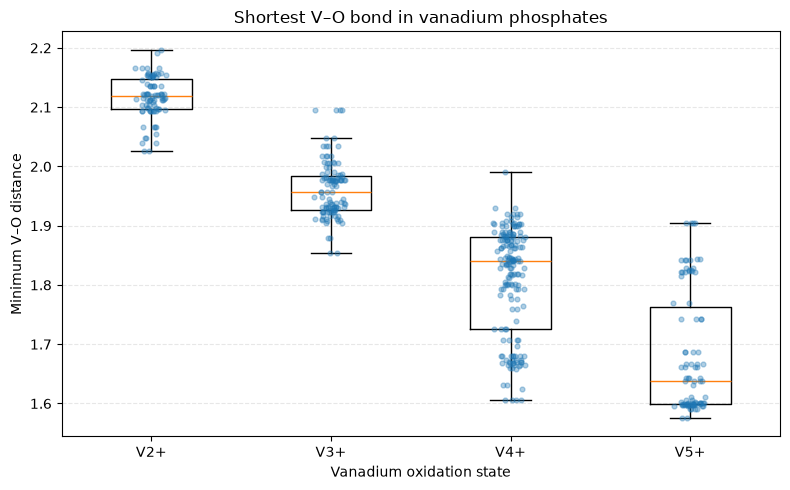

                          count   mean    std    min    25%    50%    75%  \
vanadium_oxidation_state                                                    
2                          87.0  2.117  0.035  2.025  2.097  2.120  2.148   
3                         112.0  1.961  0.048  1.854  1.927  1.957  1.983   
4                         173.0  1.809  0.090  1.605  1.725  1.840  1.881   
5                          90.0  1.680  0.102  1.575  1.599  1.638  1.763   

                            max  
vanadium_oxidation_state         
2                         2.197  
3                         2.096  
4                         1.991  
5                         1.904  


In [23]:
from scipy.stats import linregress


ox_states = sorted(df["vanadium_oxidation_state"].unique())
min_by_ox = [
    df.loc[df["vanadium_oxidation_state"] == ox, "min_VO_bond_length"].to_numpy()
    for ox in ox_states
]
labels = [f"V{int(ox)}+" for ox in ox_states]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(min_by_ox, tick_labels=labels, showfliers=False)
for i, values in enumerate(min_by_ox, start=1):
    ax.scatter(
        np.full(len(values), i) + np.random.default_rng(0).normal(0, 0.04, len(values)),
        values,
        s=12,
        alpha=0.35,
        color="C0",
        zorder=3,
    )
ax.set_xlabel("Vanadium oxidation state")
ax.set_ylabel("Minimum V–O distance")
ax.set_title("Shortest V–O bond in vanadium phosphates")
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print(df.groupby("vanadium_oxidation_state")["min_VO_bond_length"].describe().round(3))


We see that the higher valent is, the lower Minimum V–O distance is. 

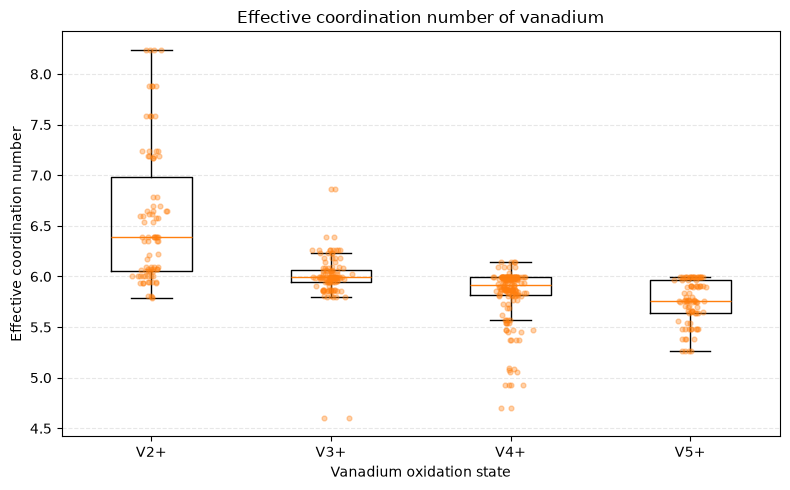

                          count   mean    std    min    25%    50%    75%  \
vanadium_oxidation_state                                                    
2                          87.0  6.575  0.672  5.789  6.053  6.387  6.980   
3                         112.0  6.003  0.257  4.601  5.944  5.995  6.067   
4                         173.0  5.824  0.282  4.696  5.813  5.919  5.993   
5                          90.0  5.759  0.213  5.263  5.643  5.761  5.968   

                            max  
vanadium_oxidation_state         
2                         8.239  
3                         6.864  
4                         6.141  
5                         5.998  


In [24]:
# Distribution of the effective coordination number of V for each oxidation state.
ecn_by_ox = [
    df.loc[df["vanadium_oxidation_state"] == ox, "effective_coordination_number"].to_numpy()
    for ox in ox_states
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(ecn_by_ox, tick_labels=labels, showfliers=False)
rng = np.random.default_rng(1)
for i, values in enumerate(ecn_by_ox, start=1):
    ax.scatter(
        np.full(len(values), i) + rng.normal(0, 0.04, len(values)),
        values,
        s=12,
        alpha=0.35,
        color="C1",
        zorder=3,
    )
ax.set_xlabel("Vanadium oxidation state")
ax.set_ylabel("Effective coordination number")
ax.set_title("Effective coordination number of vanadium")
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print(df.groupby("vanadium_oxidation_state")["effective_coordination_number"].describe().round(3))


We see that the higher valent is, the lower ECN is. 

min V-O (A) = -0.1471 * oxidation_state + 2.4045
R = -0.8882, R^2 = 0.7889, p = 1.772e-157, stderr(slope) = 0.0035


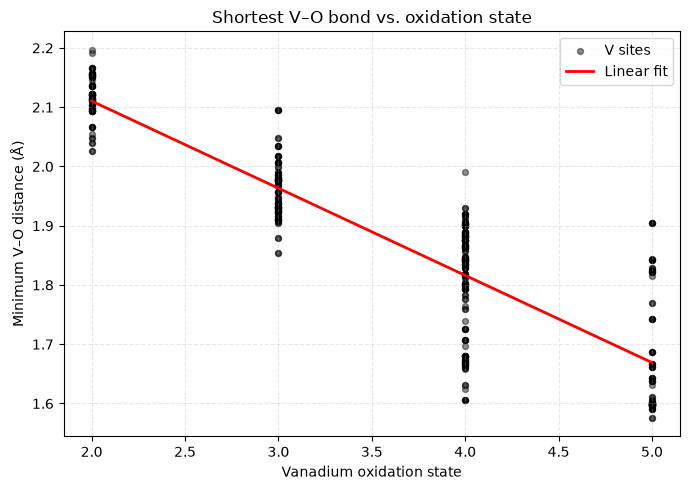

Generated structure: V5+2 P5+2 O2-10
V+5: min V-O = 1.338 A, mean V-O = 2.617 A, CN = 10, ECN = 5.23
V+5: min V-O = 1.338 A, mean V-O = 2.617 A, CN = 10, ECN = 5.23
V5+ shortest V-O in the MP set: 1.575–1.904 A (median 1.638 A)
Shortest V-O anywhere in the MP V-P-O set: 1.575 A


In [25]:

x = df["vanadium_oxidation_state"].to_numpy(dtype=float)
y = df["min_VO_bond_length"].to_numpy(dtype=float)
slope, intercept, r_value, p_value, std_err = linregress(x, y)

print(f"min V-O (A) = {slope:.4f} * oxidation_state + {intercept:.4f}")
print(f"R = {r_value:.4f}, R^2 = {r_value ** 2:.4f}, p = {p_value:.3e}, stderr(slope) = {std_err:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, s=18, alpha=0.45, color="black", label="V sites")
x_line = np.array([x.min(), x.max()])
ax.plot(x_line, slope * x_line + intercept, color="red", linewidth=2, label="Linear fit")
ax.set_xlabel("Vanadium oxidation state")
ax.set_ylabel("Minimum V–O distance (Å)")
ax.set_title("Shortest V–O bond vs. oxidation state")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



new_structure = Structure.from_file("data/VOPO4_new.cif")
new_decorated = get_oxi_state_decorated_structure(new_structure)
print("Generated structure:", new_decorated.composition)

new_rows = []
for i, site in enumerate(new_decorated.sites):
    if str(site.specie.element) != "V":
        continue
    min_vo, mean_vo, cn, ecn = get_features(vnn.get_voronoi_polyhedra(new_decorated, i))
    new_rows.append((site.specie.oxi_state, min_vo, mean_vo, cn, ecn))
    print(
        f"V{site.specie.oxi_state:+.0f}: min V-O = {min_vo:.3f} A, "
        f"mean V-O = {mean_vo:.3f} A, CN = {cn}, ECN = {ecn:.2f}"
    )

v5 = df.loc[df["vanadium_oxidation_state"] == 5, "min_VO_bond_length"]
print(
    f"V5+ shortest V-O in the MP set: {v5.min():.3f}–{v5.max():.3f} A "
    f"(median {v5.median():.3f} A)"
)
print(f"Shortest V-O anywhere in the MP V-P-O set: {df['min_VO_bond_length'].min():.3f} A")


In [26]:
print(f"Linear regression: min V-O (Å) = {slope:.4f} × ox_state + {intercept:.4f}")
print(f"  Slope:       {slope:.4f} Å per unit oxidation state")
print(f"  Intercept:   {intercept:.4f} Å")
print(f"  R:           {r_value:.4f}")
print(f"  R^2:          {r_value**2:.4f}")
print(f"  p-value:     {p_value:.3e}")
print(f"  Std error:   {std_err:.4f}")


Linear regression: min V-O (Å) = -0.1471 × ox_state + 2.4045
  Slope:       -0.1471 Å per unit oxidation state
  Intercept:   2.4045 Å
  R:           -0.8882
  R^2:          0.7889
  p-value:     1.772e-157
  Std error:   0.0035


Minimum V–O bond length vs. oxidation state. Our results show a clear decrease in the shortest V–O distance with increasing oxidation state, confirmed by linear regression. This agrees with both reference studies. Urusov reports vanadyl (V=O) bond lengths of ~1.60 A for V(5+) and ~1.60 A for V(4+), while V(3+)–O bonds are consistently longer (1.98–2.04 A) with no vanadyl bond at all. Gagne & Hawthorne provide similar values: V(5+) in tetrahedral coordination has a grand mean of 1.72 A, but the shortest individual bonds reach ~1.60 A; V(4+) vanadyl bonds peak at 1.59 A; V(3+) bonds cluster around 2.01 A. 

Effective coordination number vs. oxidation state. The decrease of ECN with oxidation state is consistent with the literature. Urusov and Gagne & Hawthorne both show that V(3+) typically adopts regular octahedral coordination (CN = 6, low distortion), while V(4+) and V(5+) form strongly distorted polyhedra — square pyramids, tetrahedra, or [1+4+1] octahedra with one very short vanadyl bond and one very long trans bond. This structural transition from symmetric octahedra V(3+) to distorted low-symmetry polyhedra V(5+) explains the non-linear drop in ECN: it is not a gradual shortening but a change in coordination geometry.

In [27]:
from pymatgen.core import Structure
from pymatgen.analysis.local_env import VoronoiNN
from scipy.stats import linregress
import numpy as np



residual_std = np.std(y - (slope * x + intercept))

print("Linear regression")
print("min V-O (A) = {:.4f} * ox_state + {:.4f}".format(slope, intercept))
print("R^2 = {:.4f}, p = {:.3e}, residual sigma = {:.3f} A".format(r_value**2, p_value, residual_std))
print()


new_structure = Structure.from_file("data/VOPO4_new.cif")
new_decorated = get_oxi_state_decorated_structure(new_structure)
print("Generated structure: {}".format(new_decorated.composition))
print()


vnn = VoronoiNN()

for i, site in enumerate(new_decorated.sites):
    if str(site.specie.element) != "V":
        continue

    oxi_state = site.specie.oxi_state
    poly_data = vnn.get_voronoi_polyhedra(new_decorated, i)
    features = get_features(poly_data)

    min_vo = features[0]
    predicted = slope * oxi_state + intercept
    z_score = (min_vo - predicted) / residual_std

    print("V site {}: V{:.0f}, min V-O = {:.3f} A".format(i, oxi_state, min_vo))
    print("  Regression prediction: {:.3f} +/- {:.3f} A (z = {:.2f})".format(predicted, residual_std, z_score))

    if abs(z_score) > 2:
        print("  Verdict: SUSPICIOUS")
    else:
        print("  Verdict: FEASIBLE")
    print()


Linear regression
min V-O (A) = -0.1471 * ox_state + 2.4045
R^2 = 0.7889, p = 1.772e-157, residual sigma = 0.076 A

Generated structure: V5+2 P5+2 O2-10

V site 0: V5, min V-O = 1.338 A
  Regression prediction: 1.669 +/- 0.076 A (z = -4.33)
  Verdict: SUSPICIOUS

V site 1: V5, min V-O = 1.338 A
  Regression prediction: 1.669 +/- 0.076 A (z = -4.33)
  Verdict: SUSPICIOUS



The regression predicted min V-O distance for both sites with with a residual standard deviation which for both samples exceeds 2 sigmas, so they are not feasible based on z-test.